In [7]:
import json
import matplotlib.pyplot as plt
import numpy as np
import random
from scipy.stats import entropy
from collections import Counter
from printer import DHPrinter

# funcs
def plot_class_distributions(examples):
    class_counts = Counter([example["category_id"] for example in examples])
    classes = list(class_counts.keys())
    counts = list(class_counts.values())
    sorted_classes, sorted_counts = zip(*sorted(class_counts.items(), key=lambda x: x[1], reverse=True))

    plt.figure(figsize=(12, 6))
    plt.bar(range(len(classes)), counts, width=1.0)
    plt.xlabel("Category IDs")
    plt.ylabel("Count")
    plt.title("Class Distribution")
    plt.tight_layout()
    
    plt.figure(figsize=(12, 6))
    plt.bar(range(len(sorted_classes)), sorted_counts, width=1.0)
    plt.ylabel("Count")
    plt.title("Class Distribution (Sorted)")
    plt.tight_layout()
    plt.show()

def compute_normalized_entropy(class_counts):
    counts = list(class_counts.values())
    probs = np.array(counts) / np.sum(counts)
    return entropy(probs) / np.log(len(probs))

def sample_to_entropy(examples, sampling_strategy="oversample", target_entropy=0.90, k=3):
    assert sampling_strategy in ("oversample", "undersample")
    should_oversample = sampling_strategy == "oversample"
    samples_dict = {}
    perc_complete = 0
    progress_printer = DHPrinter()
    
    class_counts = Counter([example["category_id"] for example in examples])
    current_entropy = compute_normalized_entropy(class_counts)
    starting_entropy = current_entropy

    # func references
    current_class_func = min if should_oversample else max
    # examples_func = examples.extend if should_oversample else examples.remove
    
    while current_entropy < target_entropy:
        # grab current majority / minority samples
        current_class = current_class_func(class_counts, key=class_counts.get) 
        samples = [example for example in examples if example["category_id"] == current_class]

        if not samples and not should_oversample:
            break

        # choose randoms to duplicate / remove
        random_samples = random.sample(samples, min(k, len(samples)))
        
        if should_oversample:
            examples.extend(random_samples)
        else:
            for sample in random_samples:
                examples.remove(sample)
            
        samples_dict[current_class] = (
            samples_dict[current_class] + len(random_samples)
            if current_class in samples_dict 
            else len(random_samples)
        )

        # update class counts and recompute normalized entropy
        if should_oversample:
            class_counts[current_class] += len(random_samples)
        else:
            class_counts[current_class] -= len(random_samples)
            if class_counts[current_class] <= 0:
                del class_counts[current_class]
        current_entropy = compute_normalized_entropy(class_counts)

        # print some loading percentage
        current_perc_complete = round((current_entropy - starting_entropy) / (target_entropy - starting_entropy), 3)
        if current_perc_complete != perc_complete:
            progress_printer.print_progress("", current_perc_complete)
        perc_complete = current_perc_complete
    progress_printer.print(f"Strategy: {sampling_strategy}, new normalized entropy: {current_entropy}, affected {sum(samples_dict.values())} samples across {len(samples_dict)} classes.")

In [2]:
import json
import tensorflow as tf

def process_and_save_json(
    dataset_type, 
    subset=None, 
    expected_examples=None, 
    expected_classes=None, 
    sampling_strategy=None,
    target_entropy=None
):
    with open(f"./train_val2017/{dataset_type}.json", "r") as f:
        dataset = json.load(f)
    
    images = dataset["images"]
    annotations = dataset["annotations"]
    categories = dataset["categories"]

    # category dict for lookup
    cat_dict = {}
    for category in categories:            
        cat_dict[category["id"]] = f"{category["supercategory"]}/{category["name"]}"

    assert len(images) == len(annotations)
    print(f"Examples in {dataset_type}: {len(images)}. Classes: {len(cat_dict)}.")
    
    examples = []
    for i in range(len(images)):
        image, annotation = images[i], annotations[i]
        assert annotation["image_id"] == image["id"]
        example = image
        category_id = annotation["category_id"]
        category_name = cat_dict[category_id]
        example["category_id"], example["category_name"] = category_id, category_name
        assert category_name.replace("\u00D7", "") in example["file_name"]
        examples.append(example)

    # subset filtering
    if subset is not None:
        # filter examples
        new_examples = list(filter(lambda example: example["category_name"].startswith(f"{subset}/"), examples))
        
        # reassign IDs
        subset_cat_set = set()
        for i in range(len(new_examples)):
            subset_cat_set.add(new_examples[i]["category_name"])
        
        reversed_subset_cat_dict = {}
        for i, category_name in enumerate(subset_cat_set):
            reversed_subset_cat_dict[category_name] = i
            
        for i in range(len(new_examples)):
            new_examples[i]["category_id"] = reversed_subset_cat_dict[new_examples[i]["category_name"]]

        subset_cat_dict = {v: k for k, v in reversed_subset_cat_dict.items()}
        
        assert len(subset_cat_set) == expected_classes
        assert len(reversed_subset_cat_dict) == expected_classes
        assert len(subset_cat_dict) == expected_classes
        assert len(new_examples) == expected_examples
        print(f"Examples in {dataset_type}({subset}): {len(new_examples)}. Classes: {len(reversed_subset_cat_dict)}.")
        
        examples, cat_dict = new_examples, subset_cat_dict

    # quick final validation
    for example in examples:
        assert cat_dict[example["category_id"]] == example["category_name"]

    # apply over/under sampling to target normalized entropy
    if sampling_strategy is not None:
        sample_to_entropy(
            examples, 
            sampling_strategy=sampling_strategy, 
            target_entropy=target_entropy
        )
        print(f"Number of examples after sampling: {len(examples)}.")
        
    with open(f"./train_val2017/{dataset_type}-processed.json", "w") as f:
        json.dump(examples, f)

    with open(f"./train_val2017/categories.json", "w") as f:
        json.dump(cat_dict, f)
    
    print("File write finished.")

# process dataset annotations into more convenient files
# Aves: train(214295), val(21226), classes: 964
process_and_save_json(
    dataset_type="train2017", 
    subset="Aves", 
    expected_examples=214295, 
    expected_classes=964,
    sampling_strategy="undersample",
    target_entropy=0.9
)

process_and_save_json(
    dataset_type="val2017", 
    subset="Aves", 
    expected_examples=21226, 
    expected_classes=964
)

Examples in train2017: 579184. Classes: 5089.
Examples in train2017(Aves): 214295. Classes: 964.


Strategy: undersample, new normalized entropy: 0.9000012699393298, affected 34200 samples across 49 classes.

Number of examples after sampling: 180095.
File write finished.
Examples in val2017: 95986. Classes: 5089.
Examples in val2017(Aves): 21226. Classes: 964.
File write finished.


Classes to augment < 188 counts saved to ./train_val2017/classes_to_augment.json
Current normalized entropy: 0.9000012699393298


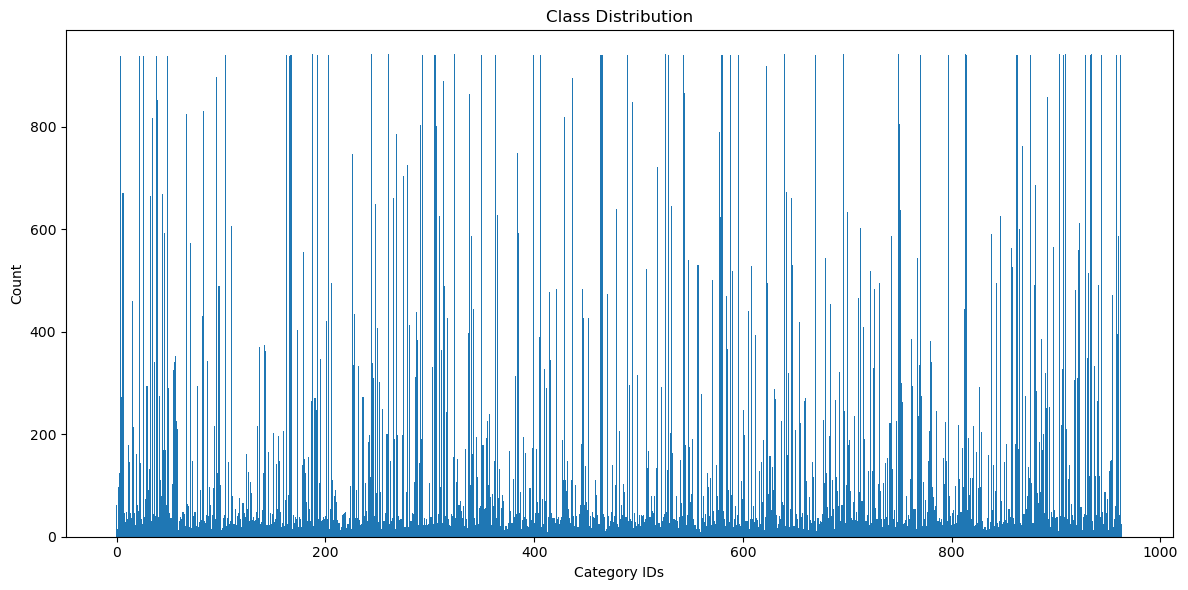

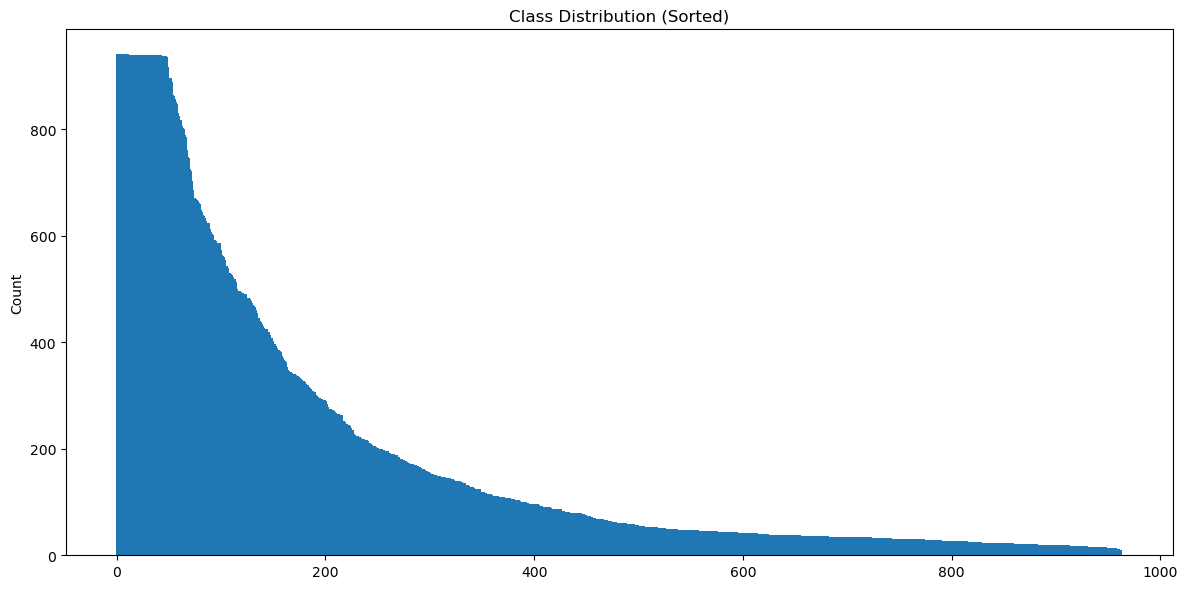

In [12]:
import math

with open("./train_val2017/train2017-processed.json", "r") as f:
    examples = json.load(f)

class_counts = Counter([example["category_id"] for example in examples])
max_count = max(class_counts.values())
threshold = math.floor(0.2 * max_count)
classes_to_augment = [cls for cls, count in class_counts.items() if count < threshold]

filepath = "./train_val2017/classes_to_augment.json"
with open(filepath, "w") as f:
    json.dump(classes_to_augment, f)
    
print(f"Classes to augment < {threshold} counts saved to {filepath}")
print(f"Current normalized entropy: {compute_normalized_entropy(Counter([example["category_id"] for example in examples]))}")
plot_class_distributions(examples)

In [11]:
print(f"max_count = {max(class_counts.values())}, min_count = {min(class_counts.values())}")

max_count = 941, min_count = 10
